In [6]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [7]:
%%R
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "ArmandoADJ"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

#setwd("Slides//Week-4-CUSUM")

[1] "Repository already cloned to Colab."


## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The Purpose of this analysis is to describe the consistency or drift of the beer pour and determine wheter the process stays consistent over time. By developing an experiment such as Phase 1 and phase 2 management can identify process drift.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

Volume of Beer dispensed per pint or Pour measured in Oz.

Continous Variable.
The Target Volume is: 16.00 Oz
The LSL is: 15.80 Oz
The USL is: 16.20 Oz

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

A CUSUM is aproppiate due to its characteristic of capturing small drift in the process, something that will seem normal and between the limits in a Shewhart chart can be easily identified with a CUSUM chart. While EWMA is also good for capturing small changes in data, its key feature to assign more weight to current observation while preserving historical information allows us to effectively capture small changes in the process.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [58]:
%%R
## Q4 Code ##
## Install and Load the Libraries ##

if(!require(qcc)) install.packages("qcc", repos = "https://cran.rstudio.com/")
library(tidyverse)
library(readxl)
library(qcc)

phase1 <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW2/BustersSportsBar_PhaseI.xlsx")
#phase1 |>
  #glimpse()

#Select only the pour measurements
measurements <- as.matrix(
  phase1[, c("Pour1", "Pour2", "Pour3", "Pour4", "Pour5")]
)

phase1_means <- rowMeans(measurements)
phase1_ranges <- apply(
  measurements, 1,
  function(x) max(x) - min(x)
)
sigma_hat <- sd.xbar(phase1,std.dev="UWAVE-SD")

print(phase1, n= 20)
print(phase1_means)
print(phase1_ranges)
#print(sigma_hat)
mu0 <- 16



# A tibble: 25 × 6
   Shift Pour1 Pour2 Pour3 Pour4 Pour5
   <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
 1     1  16.0  16.1  16.2  16.0  16.1
 2     2  16.1  16.0  16.1  16.1  16.0
 3     3  16.1  16.0  16.1  16.1  16.1
 4     4  16.0  16.2  16.1  16.0  16.0
 5     5  16.0  16.0  16.0  16.0  16.0
 6     6  16.1  16.1  16.0  15.9  16.1
 7     7  16.1  16.1  16.0  16.0  16.0
 8     8  16.2  16.0  16.1  16.0  16.1
 9     9  16.1  16.1  16.0  16.0  16.1
10    10  16.1  16.1  16.0  16.0  16.0
11    11  16.0  16.1  16.1  16.0  16.0
12    12  15.8  15.7  15.8  15.7  15.6
13    13  16.1  16.1  16.2  16.1  16.0
14    14  16.1  16.2  16.0  16.0  16.1
15    15  16.0  16.0  15.9  15.9  16.1
16    16  16.0  16.1  15.9  16.1  16.1
17    17  16.1  16.1  16.0  16.0  16.0
18    18  16.0  16.1  16.2  16.0  16.1
19    19  16.0  16.4  16.0  15.7  15.9
20    20  16.0  16.0  16.0  16.1  16.0
# ℹ 5 more rows
# ℹ Use `print(n = ...)` to see more rows
 [1] 16.08904 16.05598 16.05138 16.06778 15.98750 16.03776 16.053

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

The Chart does not show evidence of statistical control, Subgroup 19 is out of the chart limits with a subgroup range of ~ 0.7. After checking the pours for the second pour of shift 19 could have been an accident where the bartender might have tried to account for the deterioration of the CO2 regulator and overpoured the pint.

CL = 0.179536 
UCL = 0.3795391 
LCL = 0 


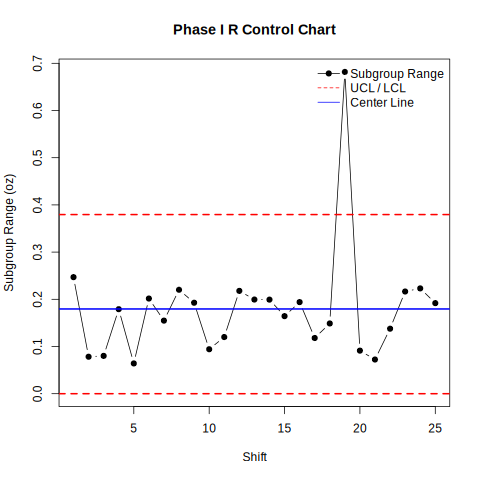

In [41]:
%%R
## Q5 Code ##

# R Chart
R_bar <- mean(phase1_ranges)
# Control chart constants for n = 5
D3 <- 0
D4 <- 2.114

# Calculate control limits
CL <- R_bar
UCL <- D4 * R_bar
LCL <- D3 * R_bar

# Plot R chart
plot(
  1:length(phase1_ranges),
  phase1_ranges,
  type = "b",
  pch = 19,
  col = "black",
  xlab = "Shift",
  ylab = "Subgroup Range (oz)",
  main = "Phase I R Control Chart",
  ylim = range(c(phase1_ranges, LCL, UCL))
)

# Add control limits
abline(h = UCL, col = "red", lty = 2, lwd = 2)
abline(h = CL, col = "blue", lty = 1, lwd = 2)
abline(h = LCL, col = "red", lty = 2, lwd = 2)

# Add legend
legend(
  "topright",
  legend = c("Subgroup Range", "UCL / LCL", "Center Line"),
  col = c("black", "red", "blue", "red"),
  lty = c(1, 2, 1, NA),
  pch = c(19, NA, NA, 19),
  bty = "n"
)

# Report results
cat("CL =", CL, "\n")
cat("UCL =", UCL, "\n")
cat("LCL =", LCL, "\n")


Removing shifts: 19 
New R-bar: 0.1586083 
New UCL: 0.335298 
New LCL: 0 
Estimated sigma: 0.06818931 


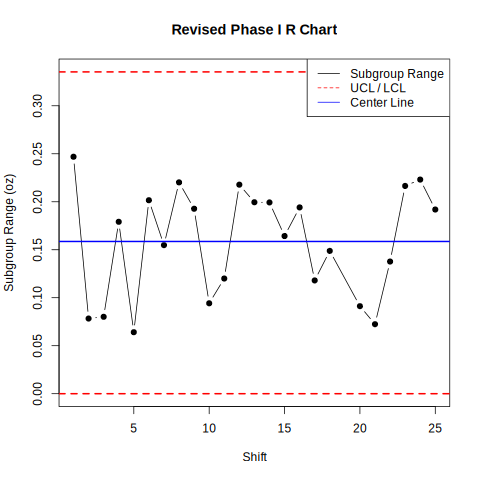

In [52]:
%%R
# Identify OOC subgroups using original limits
OOC <- which(phase1_ranges > UCL |
             phase1_ranges < LCL)

# Display removed shifts
cat("Removing shifts:", phase1$Shift[OOC], "\n")

# Create a cleaned dataset
phase1_clean <- phase1[-OOC, ]

# Recalculate subgroup statistics
measurements_clean <- as.matrix(
  phase1_clean[, c("Pour1", "Pour2", "Pour3", "Pour4", "Pour5")]
)

subgroup_means_clean <- rowMeans(measurements_clean)

subgroup_ranges_clean <- apply(
  measurements_clean, 1,
  function(x) max(x) - min(x)
)

# Recalculate process parameters
R_bar_clean <- mean(subgroup_ranges_clean)
x_double_bar_clean <- mean(subgroup_means_clean)

sigma_hat_clean <- R_bar_clean / 2.326

# Updated control limits
CL_clean <- R_bar_clean
UCL_clean <- 2.114 * R_bar_clean
LCL_clean <- 0

cat("New R-bar:", R_bar_clean, "\n")
cat("New UCL:", UCL_clean, "\n")
cat("New LCL:", LCL_clean, "\n")
cat("Estimated sigma:", sigma_hat_clean, "\n")


plot(
  phase1_clean$Shift,
  subgroup_ranges_clean,
  type = "b",
  pch = 19,
  col = "black",
  xlab = "Shift",
  ylab = "Subgroup Range (oz)",
  main = "Revised Phase I R Chart",
  ylim = range(c(subgroup_ranges_clean, LCL_clean, UCL_clean))
)

abline(h = UCL_clean, col = "red", lty = 2, lwd = 2)
abline(h = CL_clean, col = "blue", lwd = 2)
abline(h = LCL_clean, col = "red", lty = 2, lwd = 2)

legend(
  "topright",
  legend = c("Subgroup Range", "UCL / LCL", "Center Line"),
  col = c("black", "red", "blue", "red"),
  lty = c(1, 2, 1, NA), )




### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

No. The chart does not show evidence of statistical control. The subgroup out of control is the subgroup 12. This shift pour are below the lower limit for most of its pours. These OOC might have been observed due to the start of the deterioration of the C02 regulator and tap system further investigation is required to obtain a correct conclusion.

List of 11
 $ call      : language qcc(data = phase1_clean[, -1], type = "xbar", std.dev = sigma_hat_clean,      plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "phase1_clean[, -1]"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.1
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"


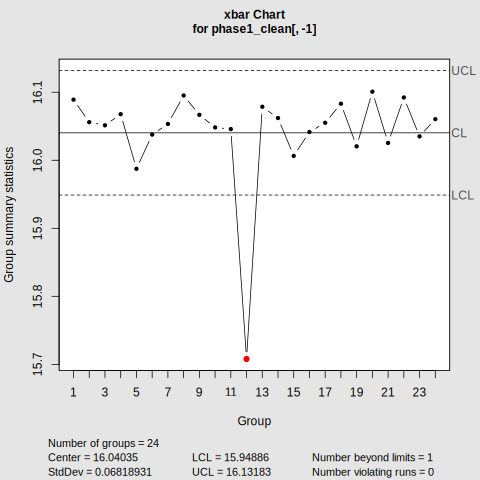

In [57]:
%%R
## Q6 Code ##


sigma_hat_clean <- sd.xbar(phase1_clean[,-1]) # This gives us s-bar/c4

qcc(phase1_clean[,-1],type="xbar",std.dev=sigma_hat_clean,plot=TRUE)

Removing original shifts: 12 
Remaining shifts: 1 2 3 4 5 6 7 8 9 10 11 13 14 15 16 17 18 20 21 22 23 24 25 


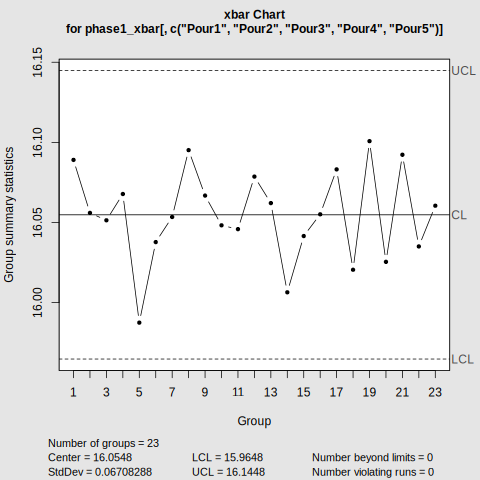

In [67]:
%%R

phase1_xbar <- phase1_clean

repeat {

  # Construct X-bar chart without plotting
  chart <- qcc(
    phase1_xbar[, c("Pour1", "Pour2", "Pour3", "Pour4", "Pour5")],
    type = "xbar",
    std.dev = "UWAVE-R",
    plot = FALSE
  )

  # Identify points outside the control limits
  OOC <- which(
    chart$statistics > chart$limits[1, 2] |
    chart$statistics < chart$limits[1, 1]
  )

  if (length(OOC) == 0) break

  # Show original shift numbers
  cat("Removing original shifts:",
      phase1_xbar$Shift[OOC], "\n")

  # Remove OOC subgroups
  phase1_xbar <- phase1_xbar[-OOC, , drop = FALSE]
}

# Plot final X-bar chart
qcc(
  phase1_xbar[, c("Pour1", "Pour2", "Pour3", "Pour4", "Pour5")],
  type = "xbar",
  std.dev = "UWAVE-R",
  plot = TRUE
)

cat("Remaining shifts:", phase1_xbar$Shift, "\n")



### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $PCR$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

PCR: 1.0062 over 1 indicating that the process spread is wider than the spec indicating high variability in the process.
Cp: 0.9938 a Value below 1 is unnaceptable producing constant defect in this case with more presence or a shift towards the upperlimit it indicates overpouring which results in less profits.
Cpk: 0.721 below 1 is unnaceptable indicating that the process is not well centered and its shifted towards the upper limit which has higher chances of overpouring.
Cpm: 0.769 Below 1 indicates that the process is unnaceptable and off the center.


Process Capability Analysis

Call:
process.capability(object = p1x, spec.limits = c(15.8, 16.2),     target = 16, nsigmas = 3)

Number of obs = 115          Target = 16
       Center = 16.05           LSL = 15.8
       StdDev = 0.06708         USL = 16.2

Capability indices:

       Value    2.5%   97.5%
Cp    0.9938  0.8649  1.1225
Cp_l  1.2661  1.1190  1.4132
Cp_u  0.7215  0.6277  0.8152
Cp_k  0.7215  0.6098  0.8332
Cpm   0.7696  0.6521  0.8870

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 1.5%	 Obs>USL 2.6%
[1] 1.006243


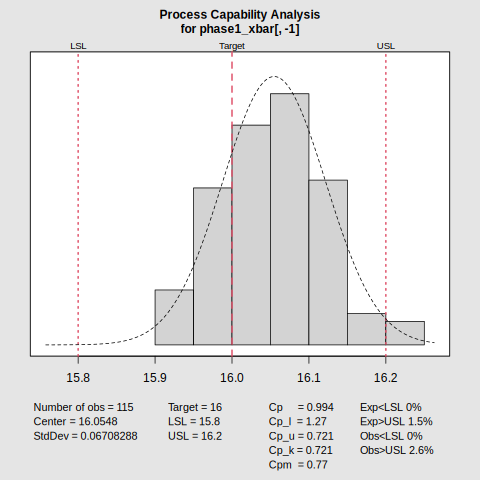

In [76]:
%%R
## Q7 Code ##

sig_hat3 <- sd.xbar(phase1_xbar[,-1])

p1x <- qcc(phase1_xbar[,-1],type="xbar",std.dev=sig_hat3,plot=TRUE)

qcc(phase1_xbar[,-1],type="S",plot=TRUE)
cap <- process.capability(p1x,spec.limits=c(15.8,16.2),target=16,nsigmas=3)

# Process Capability Ratio
PCR <- 1 / cap$indices["Cp", "Value"]

print(PCR)

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

Using the Slack Formula given by the professor: (|U1 -U0|)/ 2 = where u1 = Process mean - one standard deviation = 15.98292
Now replacing values in the slack formula: |U1-U0|/2 = 0.03354
Interval H = 5 using the rule of thumb.
Lambda = 0.2 paired with a L = 2.962 providing a moderate smoothing allowing the chart to retain historical information while remaining positive for sustained changes.


## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Yes at shift 9.

Phase I Mean: 16.0548 
Phase I Sigma: 0.06708288 
Subgroup Standard Error: 0.03000038 


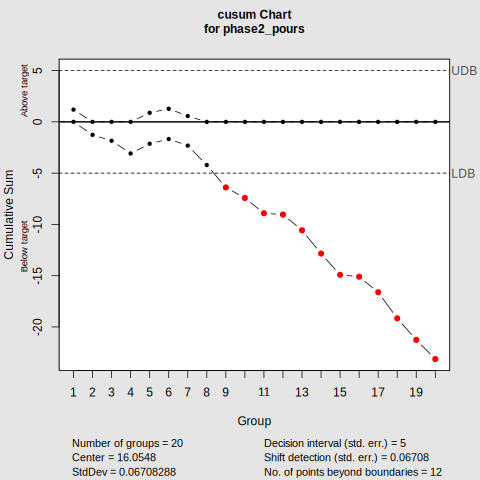

In [84]:
%%R
## Q9 Code ##
k <- 0.03354
h <- 5
library(qcc)
# Read Phase II dataset
phase2 <- read_excel("/content/STAT-7110-Quality-Control/Assignments/HW2/BustersSportsBar_PhaseII.xlsx")

# Select the five pour measurements
phase2_pours <- as.matrix(
  phase2[, c("Pour1", "Pour2", "Pour3",
             "Pour4", "Pour5")]
)

# Calculate Phase II subgroup means
phase2_means <- rowMeans(phase2_pours)

# Final Phase I estimates
mu0 <- mean(as.matrix(phase1_xbar[, -1]))
sigma0 <- sd.xbar(phase1_xbar[, -1])

# Standard error of the subgroup mean
sigma_xbar <- sigma0 / sqrt(5)

cat("Phase I Mean:", mu0, "\n")
cat("Phase I Sigma:", sigma0, "\n")
cat("Subgroup Standard Error:", sigma_xbar, "\n")


# Phase II CUSUM chart
cusum_phase2 <- cusum(
  phase2_pours,
  center = mu0,
  std.dev = sigma0,
  decision.interval = h,
  se.shift = 2 * k,
  head.start = 0,
  plot = TRUE
)


### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Yes it signal out of control conditions, at the 11th shift.

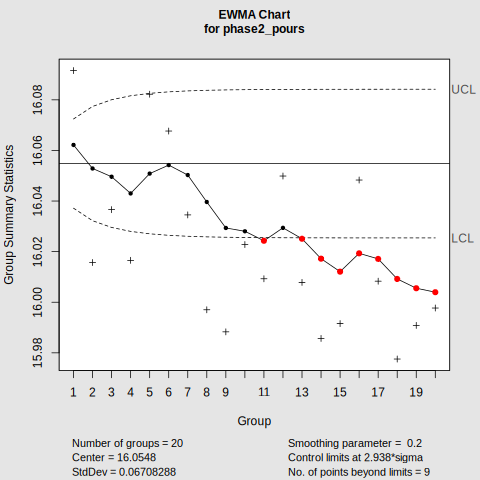

In [87]:
%%R
## Q10 Code ##



library(qcc)

## Q10 Code ##

# Final Phase I estimates
mu0 <- mean(as.matrix(phase1_xbar[, -1]))
sigma0 <- sd.xbar(phase1_xbar[, -1])

# EWMA parameters
lambda <- 0.20
L <- 2.938

# Construct Phase II EWMA chart
ewma_phase2 <- ewma(
  phase2_pours,
  center = mu0,
  std.dev = sigma0,
  lambda = lambda,
  nsigmas = L,
  plot = TRUE
)


### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

CUSUM detected the shift more quickly which is expected, this is due to CUSUM accomulating deviations from the process mean while EWMA used a smoothing parameter that can delay the shift.

In [ ]:
## Q11 Code ##

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

The analysis indicates that Buster's beer-pouring process requires corrective action. During Phase I, the process was found to be under control after addressing the out-of-control subgroups. However, the process capability analysis showed that the system was not capable of meeting the required specifications, with Cp = 0.9938 and Cpk = 0.7215, indicating an unacceptable process.

During Phase II, both control charts detected a downward shift in pour volume. The CUSUM chart signaled at Shift 9 and the EWMA chart at Shift 11. These findings are consistent with the possibility of declining CO2 regulator performance.

Taking into account these findings management should inspect the C02 regulator, tap system and improve its pouring process. If a pressure deterioration is confirmed maybe plan a scheduled ahead. For now the process should be monitored closely and after the solution is found keep monitoring the process to be certain that the solution was correct.